In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms, models, datasets
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
import time
from datetime import datetime
import seaborn as sns

2026-05-25 19:21:26.575948: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Dataset Stylegan3/Real

In [3]:
transformer_vgg16 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

train_set = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/stylegan3_real/train', transform=transformer_vgg16)
test_set = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/stylegan3_real/test', transform=transformer_vgg16)
val_set = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/stylegan3_real/val', transform=transformer_vgg16)

train_loader = DataLoader(dataset=train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(dataset=val_set, batch_size=32, shuffle=False)
test_loader = DataLoader(dataset=test_set, batch_size=32, shuffle=False)

print(f"Total no treino: {len(train_set)}")
print(f"Total na validação: {len(val_set)}")
print(f"Total no teste: {len(test_set)}")


Total no treino: 1558
Total na validação: 330
Total no teste: 334


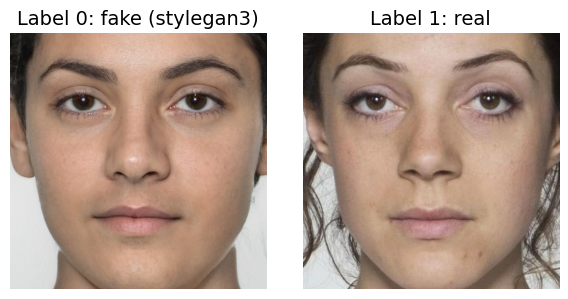

In [ ]:
dataset_vis = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/stylegan3_real/train', transform=None)
classes = dataset_vis.classes

img_real = None
img_stylegan3 = None

for img, label in dataset_vis:
    if label == 0 and img_stylegan3 is None:
        img_stylegan3 = img
        label_stylegan3 = label
    elif label == 1 and img_real is None:
        img_real = img
        label_real = label
    
    if img_real is not None and img_stylegan3 is not None:
        break

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].set_title(f"Label {label_stylegan3}: {classes[label_stylegan3]} (stylegan3)", fontsize=14)
axes[0].imshow(img_stylegan3)
axes[0].axis("off")

axes[1].set_title(f"Label {label_real}: {classes[label_real]}", fontsize=14)
axes[1].imshow(img_real)
axes[1].axis("off")


plt.tight_layout()
plt.show()

## Arquitetura

### VGG16
- Camadas de Extração de Features congeladas
- Treinamento das camadas de Classificação

#### Treinamento
- loss_fn = nn.CrossEntropyLoss()
- optimizer = optim.Adam(model.parameters(), lr=0.0001)
- acc_fn: Acurácia Simples
- EPOCHS = 5


In [5]:
class VGG16Classifier(nn.Module):
    def __init__(self, num_classes=2, freeze_features=True):
        super().__init__()        
        self.vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)        
        if freeze_features:
            for param in self.vgg16.features.parameters():
                param.requires_grad = False
                
        in_features = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(in_features, num_classes)
        
    def forward(self, x):
        return self.vgg16(x)

In [6]:
model = VGG16Classifier(num_classes=2, freeze_features=True).to(device)
print(model)

VGG16Classifier(
  (vgg16): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
    

In [7]:
summary(model, input_size=(3,244,244))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 244, 244]           1,792
              ReLU-2         [-1, 64, 244, 244]               0
            Conv2d-3         [-1, 64, 244, 244]          36,928
              ReLU-4         [-1, 64, 244, 244]               0
         MaxPool2d-5         [-1, 64, 122, 122]               0
            Conv2d-6        [-1, 128, 122, 122]          73,856
              ReLU-7        [-1, 128, 122, 122]               0
            Conv2d-8        [-1, 128, 122, 122]         147,584
              ReLU-9        [-1, 128, 122, 122]               0
        MaxPool2d-10          [-1, 128, 61, 61]               0
           Conv2d-11          [-1, 256, 61, 61]         295,168
             ReLU-12          [-1, 256, 61, 61]               0
           Conv2d-13          [-1, 256, 61, 61]         590,080
             ReLU-14          [-1, 256,

In [8]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
def acc_fn(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

In [9]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
log_dir = os.path.join('runs', f'classificacao_stylegan3_vs_real_vgg16_{timestamp}')
writer = SummaryWriter(log_dir)
print(f"Logs TensorBoard: {log_dir}")

Logs TensorBoard: runs/classificacao_stylegan3_vs_real_vgg16_20260525_192136


In [10]:
def train_model(model, loss_fn, acc_fn, optimizer, num_epochs, train_loader, val_loader, writer, checkpoint_path='checkpoints/stylegan3-classifier/'):
    since = time.time()
    
    best_model_params_path = os.path.join(checkpoint_path, 'best_vgg16_weights_stylegan3.pt')
    
    best_acc = 0.0

    for epoch in range(num_epochs):
        # Treinamento
        model.train()
        train_loss = 0.0
        train_preds = []
        train_targets = []
        
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            
            optimizer.zero_grad()
            
            #1) Forward Pass
            y_logit = model(X)
            
            #2) Loss
            loss = loss_fn(y_logit, y)
            train_loss += loss.item()
            
            #3) Métricas
            y_pred_class = torch.argmax(y_logit, dim=1)
            train_preds.extend(y_pred_class.cpu().numpy())
            train_targets.extend(y.cpu().numpy())
            
            #4) Backpropagation (dL/dW)
            loss.backward()
            
            #5) Optimizer step
            optimizer.step()
            
        train_loss /= len(train_loader)
        train_acc = acc_fn(train_targets, train_preds)

        # Validação
        model.eval()
        val_loss = 0.0

        val_preds = []
        val_targets = []
        
        with torch.inference_mode():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                #1) Forward Pass
                val_logit = model(X)
                
                #2) Loss
                val_loss += loss_fn(val_logit, y).item()
                
                #3) Métricas
                val_pred_class = torch.argmax(val_logit, dim=1)
                val_preds.extend(val_pred_class.cpu().numpy())
                val_targets.extend(y.cpu().numpy())

        val_loss /= len(val_loader)
        val_acc = acc_fn(val_targets, val_preds)

        # TensorBoard Logs
        writer.add_scalars('Loss', {'Treino': train_loss, 'Validacao': val_loss}, epoch)
        writer.add_scalars('Acuracia', {'Treino': train_acc, 'Validacao': val_acc}, epoch)

        print(f"Epoch {epoch}/{num_epochs-1}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}\n")

        # Salvamento do modelo em caso de melhor acurácia
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), best_model_params_path)

    time_elapsed = time.time() - since
    print(f'Treinamento concluído em {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    
    # Carregar os melhores pesos antes de devolver o modelo
    model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    
    return model

### Treino

In [11]:
EPOCHS = 5
trained_model = train_model(
    model=model,
    loss_fn=loss_fn,
    acc_fn=acc_fn,
    optimizer=optimizer,
    num_epochs=EPOCHS,
    train_loader=train_loader,
    val_loader=val_loader,
    writer=writer
)

Epoch 0/4
Train Loss: 0.3906 | Train Acc: 0.8126
Val Loss: 0.1474 | Val Acc: 0.9515

Epoch 1/4
Train Loss: 0.1139 | Train Acc: 0.9570
Val Loss: 0.0700 | Val Acc: 0.9758

Epoch 2/4
Train Loss: 0.0475 | Train Acc: 0.9840
Val Loss: 0.0547 | Val Acc: 0.9848

Epoch 3/4
Train Loss: 0.0310 | Train Acc: 0.9897
Val Loss: 0.0870 | Val Acc: 0.9576

Epoch 4/4
Train Loss: 0.0199 | Train Acc: 0.9923
Val Loss: 0.0395 | Val Acc: 0.9788

Treinamento concluído em 1m 50s


### Teste

In [ ]:
model.eval()

test_preds = []
test_targets = []

with torch.inference_mode():
    for X, y in test_loader:
        X,y = X.to(device), y.to(device)
        outputs = trained_model(X)
        preds = torch.argmax(outputs, dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(y.cpu().numpy())

test_acc = accuracy_score(test_targets, test_preds)
print(f"\nAcurácia no Teste: {test_acc:.4f}\n")


Acurácia no Teste: 0.9731



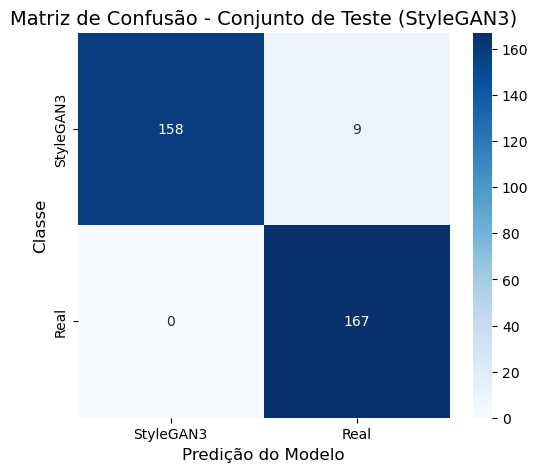

In [13]:
cm = confusion_matrix(test_targets, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['StyleGAN3', 'Real'], 
            yticklabels=['StyleGAN3', 'Real'])
plt.xlabel('Predição do Modelo', fontsize=12)
plt.ylabel('Classe', fontsize=12)
plt.title('Matriz de Confusão - Conjunto de Teste (StyleGAN3)', fontsize=14)
plt.show()

In [ ]:
import json

test_data_stylegan3 = {
    "test_acc": test_acc
}

with open('metrics_teste_stylegan3.json', 'w') as arquivo:
    json.dump(test_data_stylegan3, arquivo)